# Target by band — scoring across position × minutes band
_How `total_points` (Y) distributes at each position and minutes band: its shape, the blank-to-haul ladder, and whether scoring steps at the 60-minute mark. This notebook **owns the target distribution** for the foundation layer. DGW excluded._

**Sections:** (a) target distribution by position · (b) blank-to-haul ladder · (c) the 60-minute step

---

## Setup
> Whole season, `minutes > 0`, **DGW excluded** (`is_dgw == False`); bin minutes into the rule-aligned bands `1-29 / 30-59 / 60+`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError

POSITIONS = ["GK", "DEF", "MID", "FWD"]
BANDS = ["1-29", "30-59", "60+"]
COLOURS = {"GK": "#9467bd", "DEF": "#1f77b4", "MID": "#2ca02c", "FWD": "#d62728"}

try:
    _r = load_mart()
except (MartNotBuiltError, MartSchemaError) as _e:
    print(f"Rebuilding mart ({type(_e).__name__})...")
    run_pipeline(force=True)
    _r = load_mart()

mart = _r.mart
df = mart[mart["gw"].between(1, _r.data_cutoff_gw)].copy()
df = df[df["minutes"].notna() & (df["minutes"] > 0)].copy()
df = df[df["is_dgw"] == False].copy()


def _band(mn):
    return "1-29" if mn < 30 else "30-59" if mn < 60 else "60+"


df["band"] = df["minutes"].astype(int).map(_band)
cohorts = {p: df[df.position == p] for p in POSITIONS}
print(f"Study range: GW 1 - {_r.data_cutoff_gw} · minutes > 0 · DGW excluded · n = {len(df):,}")
for p in POSITIONS:
    print(f"  {p}: {len(cohorts[p]):>6,}")

Study range: GW 1 - 38 · minutes > 0 · DGW excluded · n = 11,190
  GK:    747
  DEF:  3,845
  MID:  5,208
  FWD:  1,390


## (a) Target distribution by position
> What shape does `total_points` take at each position?

Season-pooled `total_points` per position (DGW excluded). Each distribution is zero-inflated and right-skewed — a spike at the appearance floor with a thin haul tail — which is why this layer reads medians, quantiles and rates rather than means.

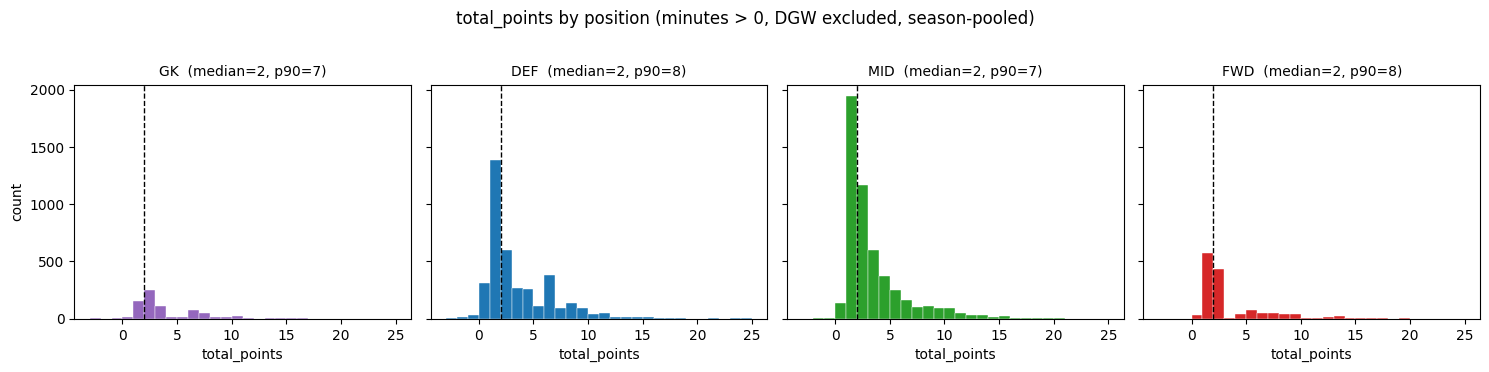

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=True)
bins = range(int(df["total_points"].min()), int(df["total_points"].max()) + 2)
for ax, p in zip(axes, POSITIONS):
    s = cohorts[p]["total_points"].dropna()
    ax.hist(s, bins=bins, color=COLOURS[p], edgecolor="white", linewidth=0.3)
    ax.axvline(s.median(), color="black", linestyle="--", linewidth=1.0)
    ax.set_title(f"{p}  (median={s.median():.0f}, p90={s.quantile(0.9):.0f})", fontsize=10)
    ax.set_xlabel("total_points")
axes[0].set_ylabel("count")
fig.suptitle("total_points by position (minutes > 0, DGW excluded, season-pooled)", y=1.02)
plt.tight_layout()
plt.show()

## (b) Blank-to-haul ladder
> How often does each position × band blank, return, or haul?

Share of appearances clearing each threshold — strict blank (=0), effective blank (<=2), returns (>=4 / >=6 / >=8) and haul (>10) — per position and minutes band. Each row reads left-to-right from floor to ceiling; compare bands within a position to see where returns concentrate.

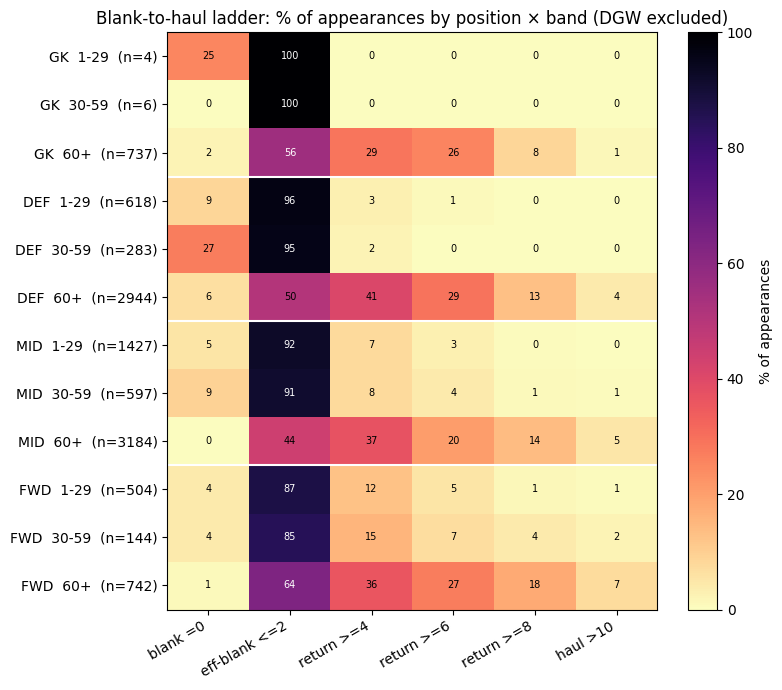

In [3]:
LADDER = [
    ("blank =0", lambda y: (y == 0).mean() * 100),
    ("eff-blank <=2", lambda y: (y <= 2).mean() * 100),
    ("return >=4", lambda y: (y >= 4).mean() * 100),
    ("return >=6", lambda y: (y >= 6).mean() * 100),
    ("return >=8", lambda y: (y >= 8).mean() * 100),
    ("haul >10", lambda y: (y > 10).mean() * 100),
]
index, M = [], []
for p in POSITIONS:
    for b in BANDS:
        y = df.loc[(df.position == p) & (df.band == b), "total_points"].astype(float)
        index.append(f"{p}  {b}  (n={len(y)})")
        M.append([f(y) if len(y) else np.nan for _, f in LADDER])
M = np.array(M, dtype=float)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(np.ma.masked_invalid(M), cmap="magma_r", aspect="auto", vmin=0, vmax=100)
ax.set_xticks(range(len(LADDER))); ax.set_xticklabels([n for n, _ in LADDER], rotation=30, ha="right")
ax.set_yticks(range(len(index))); ax.set_yticklabels(index)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        v = M[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7,
                    color="white" if v > 55 else "black")
    if i % 3 == 2 and i < M.shape[0] - 1:
        ax.axhline(i + 0.5, color="white", linewidth=1.5)
ax.set_title("Blank-to-haul ladder: % of appearances by position × band (DGW excluded)")
fig.colorbar(im, ax=ax, label="% of appearances")
plt.tight_layout()
plt.show()

## (c) The 60-minute step
> Does typical scoring step up at 60 minutes, or ramp smoothly?

Median `total_points` by position and band. A flat 1-29 / 30-59 then a jump at 60+ marks 60 as a regime boundary (clean-sheet eligibility, the second appearance point); a smooth ramp would not.

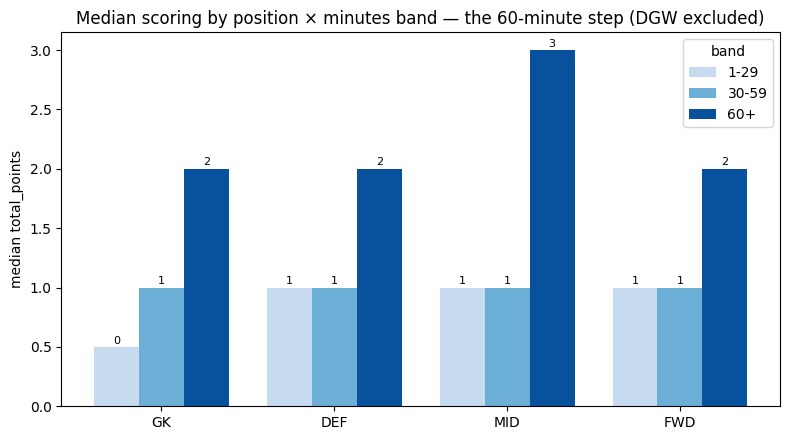

In [4]:
med = df.groupby(["position", "band"])["total_points"].median().unstack("band").reindex(POSITIONS)[BANDS]

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(POSITIONS))
w = 0.26
band_colours = {"1-29": "#c6dbef", "30-59": "#6baed6", "60+": "#08519c"}
for k, b in enumerate(BANDS):
    vals = med[b].to_numpy()
    bars = ax.bar(x + (k - 1) * w, vals, w, color=band_colours[b], label=b)
    ax.bar_label(bars, fmt="%.0f", fontsize=8, padding=1)
ax.set_xticks(x); ax.set_xticklabels(POSITIONS)
ax.set_ylabel("median total_points")
ax.set_title("Median scoring by position × minutes band — the 60-minute step (DGW excluded)")
ax.legend(title="band")
plt.tight_layout()
plt.show()